In [ ]:
N_DOCS               = 3
FORCE_FULL_PRECISION = False
FORCE_4BIT           = False
SHOW_FIRST_PAGE      = True
RUN_ON_REAL_PDF      = False
REAL_PDF_URL         = "https://arxiv.org/pdf/1512.03385"
REAL_PDF_PAGES       = "0-3"
PIN_PILLOW           = True
PILLOW_VERSION       = "11.3.0"

import os, sys, subprocess, json, re, time, warnings
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def pip(*pkgs, upgrade=False):
    """Install without invoking a shell (so '[hf]' is never glob-expanded)."""
    args = [sys.executable, "-m", "pip", "install", "-q"] + (["-U"] if upgrade else []) + list(pkgs)
    print("  pip install", *pkgs)
    subprocess.run(args, check=False)

print("STEP 1/7 · Installing lift + light dependencies (first run is the slow one)…")
pip("reportlab", "pypdfium2", "pandas", "matplotlib")
pip("lift-pdf[hf]")
pip("bitsandbytes", "accelerate", upgrade=True)

if PIN_PILLOW:
    pip(f"pillow=={PILLOW_VERSION}")

    if "PIL" in sys.modules:
        import PIL
        if getattr(PIL, "__version__", "") != PILLOW_VERSION:
            print(f"     Pinned Pillow {PILLOW_VERSION} on disk, but a stale Pillow "
                  f"({getattr(PIL, '__version__', '?')}) is already loaded in memory.")
            print("     Restarting the runtime now — just re-run the cell(s) after it reconnects.")
            os.kill(os.getpid(), 9)

print("     …install finished.\n")

import torch

In [ ]:
def detect_gpu():
    if not torch.cuda.is_available():
        raise SystemExit(
            "\n✗ No CUDA GPU found. In Colab: Runtime ▸ Change runtime type ▸ GPU "
            "(A100 is best; L4/T4 also work).\n"
        )
    p  = torch.cuda.get_device_properties(0)
    cc = torch.cuda.get_device_capability(0)
    return p.name, p.total_memory / 1e9, cc

def enable_4bit(compute_dtype):
    """
    Load lift's weights in 4-bit NF4 no matter which transformers Auto* class it uses
    internally. We inject a quantization_config + on-GPU device_map, and neutralize any
    later model.to()/.cuda() (which is illegal on a bnb-quantized model). This is what lets
    a ~10 B model fit on a 16 GB T4 / 24 GB L4.
    """
    import inspect, functools, transformers
    from transformers import BitsAndBytesConfig
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=compute_dtype,
    )

    def patch(cls):
        try:
            cm   = inspect.getattr_static(cls, "from_pretrained")
            orig = cm.__func__ if isinstance(cm, (classmethod, staticmethod)) else cm
        except Exception:
            return

        @functools.wraps(orig)
        def inner(cls_, *args, **kwargs):
            kwargs.setdefault("quantization_config", bnb)
            kwargs.setdefault("device_map", {"": 0})
            model = orig(cls_, *args, **kwargs)
            try:
                model.to   = lambda *a, **k: model
                model.cuda = lambda *a, **k: model
            except Exception:
                pass
            return model

        cls.from_pretrained = classmethod(inner)

    for name in ["AutoModelForImageTextToText", "AutoModelForMultimodalLM",
                 "AutoModelForVision2Seq", "AutoModelForCausalLM", "AutoModel"]:
        c = getattr(transformers, name, None)
        if c is not None:
            patch(c)
    try:
        from transformers.modeling_utils import PreTrainedModel
        patch(PreTrainedModel)
    except Exception:
        pass

print("STEP 2/7 · Preparing the model backend…")
gpu_name, vram, cc = detect_gpu()
use_4bit      = FORCE_4BIT or (vram < 34 and not FORCE_FULL_PRECISION)
compute_dtype = torch.bfloat16 if cc[0] >= 8 else torch.float16
print(f"     GPU: {gpu_name} | ~{vram:.0f} GB | compute capability {cc[0]}.{cc[1]}")
print(f"     Load mode: {'4-bit NF4' if use_4bit else 'full bf16'} (compute dtype {compute_dtype})")

os.environ.setdefault("TORCH_DEVICE", "cuda:0")
os.environ.setdefault("MODEL_CHECKPOINT", "datalab-to/lift")
if use_4bit:
    enable_4bit(compute_dtype)

from lift import extract
from lift.model import InferenceManager

print("     Loading lift weights (≈20 GB download on first run)…")
_t = time.time()
MODEL = InferenceManager(method="hf")
print(f"     ✓ model ready in {time.time() - _t:.0f}s\n")

def run_lift(pdf_path, schema, page_range=None):
    kw = {"model": MODEL}
    if page_range:
        kw["page_range"] = page_range
    result = extract(pdf_path, schema, **kw)
    return getattr(result, "extraction", None)

In [ ]:
DOCS = [
    dict(
        title="SolarNet: Efficient Land-Cover Classification from Multispectral Satellite Imagery",
        authors=[("Maya Okafor", "TU Delft"),
                 ("Liang Wei", "TU Delft"),
                 ("Priya Ramachandran", "European Space Research Institute")],
        task="satellite image land-cover classification",
        method="SolarNet",
        datasets=["EuroSAT", "BigEarthNet", "So2Sat"],
        primary_benchmark="EuroSAT",
        metric_name="Top-1 accuracy",
        test_acc=96.4, val_acc=97.1, baseline_name="ResNet-50",
        baseline_val=92.0, baseline_test=91.2,
        params_m=42.7, optimizer="AdamW", lr=0.0003, batch=128, epochs=90,
        beats_sota=True, prior_best=95.1,
        code_url=None,
        funding_note="This work was supported by the Open Earth Initiative. "
                     "The authors do not release source code for the trained models.",
        limitations=["Accuracy degrades on scenes with heavy cloud cover.",
                     "Trained only on imagery at 10 m spatial resolution."],
    ),
    dict(
        title="GraphMoE: Mixture-of-Experts Message Passing for Molecular Property Prediction",
        authors=[("Sofia Álvarez", "ETH Zürich"),
                 ("Daniel Kim", "ETH Zürich"),
                 ("Yara Haddad", "Genentech"),
                 ("Tom Becker", "ETH Zürich")],
        task="molecular property prediction",
        method="GraphMoE",
        datasets=["OGB-MolHIV", "QM9", "ZINC"],
        primary_benchmark="OGB-MolHIV",
        metric_name="ROC-AUC",
        test_acc=0.812, val_acc=0.828, baseline_name="GIN",
        baseline_val=0.784, baseline_test=0.771,
        params_m=8.3, optimizer="Adam", lr=0.001, batch=256, epochs=120,
        beats_sota=True, prior_best=0.799,
        code_url="https://github.com/mol-ai/graphmoe",
        funding_note="Funded by the Swiss NSF. Code and pretrained checkpoints are available "
                     "at https://github.com/mol-ai/graphmoe.",
        limitations=["Expert routing adds ~15% inference latency versus a dense GNN.",
                     "Evaluated only on small-molecule datasets under 50 heavy atoms."],
    ),
    dict(
        title="AcoustiFormer: A Compact Transformer for Environmental Sound Classification",
        authors=[("Noah Fischer", "University of Edinburgh"),
                 ("Aisha Bello", "University of Edinburgh"),
                 ("Kenji Watanabe", "Sony CSL")],
        task="environmental sound classification",
        method="AcoustiFormer",
        datasets=["ESC-50", "UrbanSound8K"],
        primary_benchmark="ESC-50",
        metric_name="accuracy",
        test_acc=88.7, val_acc=90.3, baseline_name="CNN14",
        baseline_val=90.8, baseline_test=89.2,
        params_m=22.1, optimizer="AdamW", lr=0.0005, batch=64, epochs=200,
        beats_sota=False, prior_best=89.2,
        code_url="https://github.com/audio-lab/acoustiformer",
        funding_note="Code available at https://github.com/audio-lab/acoustiformer.",
        limitations=["A larger CNN baseline still outperforms our model on ESC-50.",
                     "Performance was not evaluated on real-time streaming audio."],
    ),
][:N_DOCS]

def ground_truth(d):
    """Reshape a source dict into the exact JSON shape our schema asks for."""
    return {
        "title": d["title"],
        "authors": [{"name": n, "affiliation": a} for (n, a) in d["authors"]],
        "primary_task": d["task"],
        "proposed_method_name": d["method"],
        "datasets": d["datasets"],
        "headline_metric": {"name": d["metric_name"],
                            "value": d["test_acc"],
                            "benchmark": d["primary_benchmark"]},
        "num_parameters_millions": d["params_m"],
        "hyperparameters": {"optimizer": d["optimizer"], "learning_rate": d["lr"],
                            "batch_size": d["batch"], "epochs": d["epochs"]},
        "beats_prior_sota": d["beats_sota"],
        "code_url": d["code_url"],
        "limitations": d["limitations"],
    }

In [ ]:
def render_pdf(d, path):
    """Draw a realistic 3-page report. Page breaks are forced so the headline metric on
    page 1 (abstract) is physically separated from the results table on page 3."""
    from reportlab.lib.pagesizes import LETTER
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    from reportlab.lib import colors
    from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                    Table, TableStyle, PageBreak)

    ss = getSampleStyleSheet()
    H1   = ParagraphStyle("H1", parent=ss["Title"], fontSize=16, leading=20, spaceAfter=6)
    AUTH = ParagraphStyle("AUTH", parent=ss["Normal"], fontSize=9.5, textColor=colors.grey, spaceAfter=10)
    H2   = ParagraphStyle("H2", parent=ss["Heading2"], fontSize=12, spaceBefore=8, spaceAfter=4)
    BODY = ParagraphStyle("BODY", parent=ss["Normal"], fontSize=10, leading=14, spaceAfter=6)

    sota_phrase = (f"surpassing the previous best of {d['prior_best']}"
                   if d["beats_sota"] else
                   f"approaching but not exceeding the previous best of {d['prior_best']}")
    authors_line = ", ".join(f"{n} ({a})" for (n, a) in d["authors"])

    story = []
    story += [Paragraph(d["title"], H1), Paragraph(authors_line, AUTH), Paragraph("Abstract", H2)]
    story += [Paragraph(
        f"We introduce {d['method']}, a model for {d['task']}. On the {d['primary_benchmark']} "
        f"benchmark, {d['method']} attains {d['test_acc']} {d['metric_name']} on the held-out "
        f"test set, {sota_phrase}. Our {d['params_m']}M-parameter model is evaluated across "
        f"{len(d['datasets'])} datasets ({', '.join(d['datasets'])}). "
        f"Extensive ablations confirm the contribution of each component.", BODY)]
    story += [Paragraph("Keywords", H2),
              Paragraph(f"{d['task']}; representation learning; {d['primary_benchmark']}", BODY),
              PageBreak()]

    story += [Paragraph("1  Method and Training Details", H2)]
    story += [Paragraph(
        f"{d['method']} is trained end-to-end with the {d['optimizer']} optimizer. "
        f"We tune on a validation split and report final numbers on the test split. "
        f"The full training configuration is summarized in Table 1.", BODY)]
    hp = [["Hyperparameter", "Value"],
          ["Optimizer", d["optimizer"]],
          ["Learning rate", str(d["lr"])],
          ["Batch size", str(d["batch"])],
          ["Epochs", str(d["epochs"])],
          ["Parameters", f"{d['params_m']}M"]]
    t1 = Table(hp, colWidths=[2.4 * inch, 2.0 * inch])
    t1.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#2b3a67")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("GRID", (0, 0), (-1, -1), 0.4, colors.grey),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#eef1f8")]),
        ("LEFTPADDING", (0, 0), (-1, -1), 8), ("TOPPADDING", (0, 0), (-1, -1), 4),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 4)]))
    story += [Spacer(1, 4), t1, Spacer(1, 6),
              Paragraph("<b>Table 1.</b> Training configuration.", BODY),
              Paragraph("2  Datasets", H2),
              Paragraph(
                  f"We evaluate on {', '.join(d['datasets'])}. {d['primary_benchmark']} is our "
                  f"primary benchmark; the remaining datasets are used for generalization "
                  f"studies.", BODY),
              PageBreak()]

    story += [Paragraph("3  Results", H2)]
    res = [["Method", f"Val. {d['metric_name']}", f"Test {d['metric_name']}"],
           [f"{d['baseline_name']} (baseline)", str(d["baseline_val"]), str(d["baseline_test"])],
           [f"{d['method']} (ours)", str(d["val_acc"]), str(d["test_acc"])]]
    t2 = Table(res, colWidths=[2.6 * inch, 1.7 * inch, 1.7 * inch])
    t2.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#7a2e2e")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTSIZE", (0, 0), (-1, -1), 9.5),
        ("GRID", (0, 0), (-1, -1), 0.4, colors.grey),
        ("FONTNAME", (0, 2), (-1, 2), "Helvetica-Bold"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#f7eeee")]),
        ("LEFTPADDING", (0, 0), (-1, -1), 8), ("TOPPADDING", (0, 0), (-1, -1), 4),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 4)]))
    story += [Spacer(1, 4), t2, Spacer(1, 6),
              Paragraph(f"<b>Table 2.</b> Results on {d['primary_benchmark']}. "
                        f"Best test result in bold.", BODY),
              Paragraph("4  Limitations", H2)]
    for lim in d["limitations"]:
        story += [Paragraph("• " + lim, BODY)]
    story += [Paragraph("5  Funding and Code Availability", H2),
              Paragraph(d["funding_note"], BODY)]

    SimpleDocTemplate(path, pagesize=LETTER,
                      topMargin=0.8 * inch, bottomMargin=0.8 * inch,
                      leftMargin=0.9 * inch, rightMargin=0.9 * inch).build(story)

print("STEP 3/7 · Generating synthetic report PDFs…")
CORPUS = []
for i, d in enumerate(DOCS):
    path = f"/content/report_{i}.pdf" if os.path.isdir("/content") else f"report_{i}.pdf"
    render_pdf(d, path)
    CORPUS.append((d, ground_truth(d), path))
    print(f"     ✓ {os.path.basename(path)}  —  {d['method']}")
print()

if SHOW_FIRST_PAGE:
    try:
        import pypdfium2 as pdfium, matplotlib.pyplot as plt
        pg  = pdfium.PdfDocument(CORPUS[0][2])[0]
        img = pg.render(scale=2.0).to_pil()
        plt.figure(figsize=(6.4, 8.3)); plt.imshow(img); plt.axis("off")
        plt.title("What lift reads — page 1 of report_0.pdf", fontsize=10); plt.show()
    except Exception as e:
        print("     (page preview skipped:", e, ")\n")

In [ ]:
SCHEMA = {
    "type": "object",
    "properties": {
        "title": {"type": "string", "description": "The full title of the paper"},
        "authors": {
            "type": "array",
            "description": "Every author listed, in order",
            "items": {"type": "object", "properties": {
                "name":        {"type": "string"},
                "affiliation": {"type": "string", "description": "The author's institution"},
            }},
        },
        "primary_task": {"type": "string",
                         "description": "The main machine-learning task the paper addresses"},
        "proposed_method_name": {"type": "string",
                                 "description": "Name of the model/method the paper introduces "
                                                "(not a baseline it compares against)"},
        "datasets": {"type": "array", "items": {"type": "string"},
                     "description": "All benchmark datasets the paper evaluates on"},
        "headline_metric": {
            "type": "object",
            "description": "The primary reported result for the proposed method",
            "properties": {
                "name":      {"type": "string", "description": "Metric name, e.g. Top-1 accuracy or ROC-AUC"},
                "value":     {"type": "number", "description": "The proposed method's value for this metric on "
                                                              "the PRIMARY benchmark's TEST set — not the "
                                                              "validation number and not a baseline's number"},
                "benchmark": {"type": "string", "description": "The dataset the headline metric is reported on"},
            }},
        "num_parameters_millions": {"type": "number",
                                    "description": "Total parameter count of the proposed model, in millions"},
        "hyperparameters": {
            "type": "object",
            "properties": {
                "optimizer":     {"type": "string"},
                "learning_rate": {"type": "number"},
                "batch_size":    {"type": "integer"},
                "epochs":        {"type": "integer"},
            }},
        "beats_prior_sota": {"type": "boolean",
                             "description": "true only if the paper claims its proposed method beats the "
                                            "previous state of the art on the primary benchmark; otherwise false"},
        "code_url": {"type": "string",
                     "description": "URL of the released source-code repository. Return null if the paper "
                                    "does not release code"},
        "limitations": {"type": "array", "items": {"type": "string"},
                        "description": "Limitations the authors explicitly acknowledge"},
    },
    "required": ["title", "proposed_method_name", "headline_metric"],
}

In [ ]:
def _norm(s):
    return re.sub(r"\s+", " ", str(s).strip().lower()).strip(" .,:;/")

def _num(x):
    try:    return float(str(x).replace("%", "").replace(",", "").strip())
    except Exception: return None

def leaf_equal(gt, pr):
    if gt is None and pr is None:                       return True
    if gt is None or pr is None:                        return False
    if isinstance(gt, bool) or isinstance(pr, bool):    return bool(gt) == bool(pr)
    a, b = _num(gt), _num(pr)
    if a is not None and b is not None:
        return abs(a - b) < 1e-6 if b == 0 else abs(a - b) / max(abs(a), abs(b)) < 5e-3
    return _norm(gt) == _norm(pr)

def flatten(o, prefix=""):
    out = {}
    if isinstance(o, dict):
        for k, v in o.items():
            out.update(flatten(v, f"{prefix}.{k}" if prefix else k))
    elif isinstance(o, list):
        for i, v in enumerate(o):
            out.update(flatten(v, f"{prefix}[{i}]"))
    else:
        out[prefix] = o
    return out

def score(gt, pred):
    fg, fp = flatten(gt), flatten(pred or {})
    rows, correct = [], 0
    for key, gv in fg.items():
        present = key in fp
        pv = fp.get(key)
        ok = (gv is None and (not present or pv is None)) or (present and leaf_equal(gv, pv))
        correct += int(ok)
        rows.append((key, gv, (pv if present else None), ok))
    return (correct / len(fg) if fg else 0.0), rows

print("STEP 4/7 · Extracting with lift and scoring against ground truth…\n")
results = []
for i, (src, gt, path) in enumerate(CORPUS):
    t0 = time.time()
    pred = run_lift(path, SCHEMA)
    dt = time.time() - t0
    acc, rows = score(gt, pred)
    results.append(dict(src=src, gt=gt, pred=pred, acc=acc, rows=rows, seconds=dt))
    print(f"     doc {i} · {src['method']:<14} field accuracy {acc*100:5.1f}%   ({dt:.1f}s)")

r0 = results[0]
print("\n" + "=" * 90)
print(f"DETAILED VIEW · document 0 · {r0['src']['method']}")
print("=" * 90)
print("Raw JSON lift returned (guaranteed to match the schema shape):\n")
print(json.dumps(r0["pred"], indent=2, ensure_ascii=False))

import pandas as pd
pd.set_option("display.max_colwidth", 46)
pd.set_option("display.width", 120)
grade = pd.DataFrame([{"field": k,
                       "ground_truth": ("∅ (null)" if g is None else g),
                       "lift_predicted": ("∅ (null)" if p is None else p),
                       "✓": "✓" if ok else "✗"}
                      for (k, g, p, ok) in r0["rows"]])
print("\nField-by-field grade:\n")
print(grade.to_string(index=False))

print("\nWhat to look for:")
print("  • headline_metric.value should be the TEST number, not the higher validation number,")
print("    and not the baseline row — that's the near-miss-distractor test.")
print("  • code_url should be ∅ (null): report 0 explicitly releases no code (abstention).")
print("  • every author + affiliation and every dataset should be present (exhaustive lists).")

STEP 1/7 · Installing lift + light dependencies (first run is the slow one)…
  pip install reportlab pypdfium2 pandas matplotlib
  pip install lift-pdf[hf]
  pip install bitsandbytes accelerate
  pip install pillow==11.3.0
     …install finished.

STEP 2/7 · Preparing the model backend…
     GPU: Tesla T4 | ~16 GB | compute capability 7.5
     Load mode: 4-bit NF4 (compute dtype torch.float16)
     Loading lift weights (≈20 GB download on first run)…


config.json:   0%|          | 0.00/2.78k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/19.3G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

     ✓ model ready in 331s

STEP 3/7 · Generating synthetic report PDFs…
     ✓ report_0.pdf  —  SolarNet
     ✓ report_1.pdf  —  GraphMoE
     ✓ report_2.pdf  —  AcoustiFormer



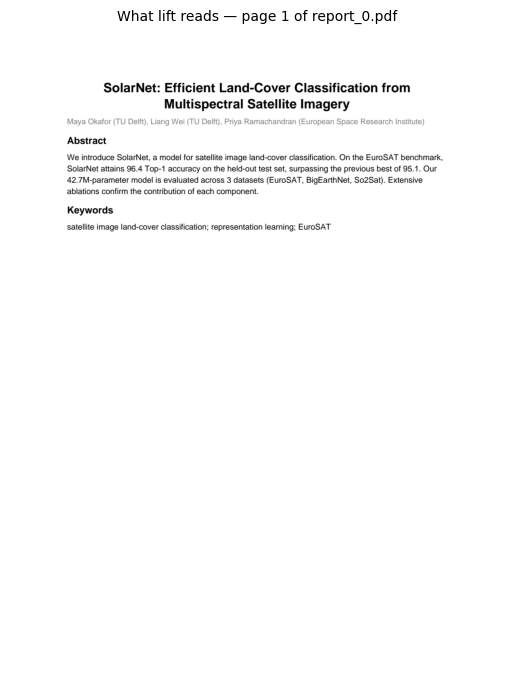

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


STEP 4/7 · Extracting with lift and scoring against ground truth…



[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


     doc 0 · SolarNet       field accuracy 100.0%   (134.0s)


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


     doc 1 · GraphMoE       field accuracy 100.0%   (139.2s)


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


     doc 2 · AcoustiFormer  field accuracy 100.0%   (133.6s)

DETAILED VIEW · document 0 · SolarNet
Raw JSON lift returned (guaranteed to match the schema shape):

{
  "title": "SolarNet: Efficient Land-Cover Classification from Multispectral Satellite Imagery",
  "authors": [
    {
      "name": "Maya Okafor",
      "affiliation": "TU Delft"
    },
    {
      "name": "Liang Wei",
      "affiliation": "TU Delft"
    },
    {
      "name": "Priya Ramachandran",
      "affiliation": "European Space Research Institute"
    }
  ],
  "primary_task": "satellite image land-cover classification",
  "proposed_method_name": "SolarNet",
  "datasets": [
    "EuroSAT",
    "BigEarthNet",
    "So2Sat"
  ],
  "headline_metric": {
    "name": "Top-1 accuracy",
    "value": 96.4,
    "benchmark": "EuroSAT"
  },
  "num_parameters_millions": 42.7,
  "hyperparameters": {
    "optimizer": "AdamW",
    "learning_rate": 0.0003,
    "batch_size": 128,
    "epochs": 90
  },
  "beats_prior_sota": true,
  "code

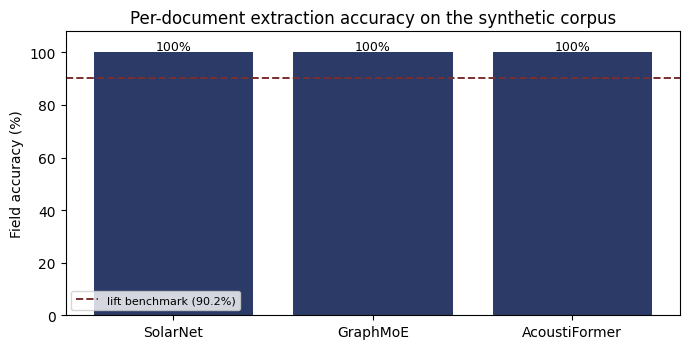


STEP 7/7 · (skipped) set RUN_ON_REAL_PDF = True to also mine a real arXiv PDF.

✅ Done. You now have: schema-valid extractions, a scored grade, and a knowledge base.
   Next: swap in your own PDFs + schema, or reuse MODEL across thousands of files.


In [1]:
print("\n" + "=" * 90)
print("STEP 5/7 · Assembling the extractions into a queryable research knowledge base")
print("=" * 90)

def g(d, path, default=None):
    cur = d
    for key in path.split("."):
        if isinstance(cur, dict) and cur.get(key) is not None:
            cur = cur[key]
        else:
            return default
    return cur

kb = pd.DataFrame([{
    "method":     g(r["pred"], "proposed_method_name"),
    "task":       g(r["pred"], "primary_task"),
    "benchmark":  g(r["pred"], "headline_metric.benchmark"),
    "metric":     g(r["pred"], "headline_metric.name"),
    "score":      g(r["pred"], "headline_metric.value"),
    "params_M":   g(r["pred"], "num_parameters_millions"),
    "beats_sota": g(r["pred"], "beats_prior_sota"),
    "authors":    len(g(r["pred"], "authors", []) or []),
    "code":       g(r["pred"], "code_url"),
    "field_acc":  round(r["acc"], 3),
} for r in results])

print("\nResearch knowledge base (one row per mined paper):\n")
print(kb.to_string(index=False))

print("\nExample query — papers that claim to beat SOTA, best result first:\n")
won = kb[kb["beats_sota"] == True].sort_values("score", ascending=False)
print((won if len(won) else "  (none in this sample)").to_string(index=False) if len(won) else "  (none)")

overall = sum(r["acc"] for r in results) / len(results)
print(f"\nSTEP 6/7 · Overall field accuracy across {len(results)} documents: {overall*100:.1f}%")
print("     (Datalab report lift at ~90.2% field accuracy on their 225-doc benchmark.)")

try:
    import matplotlib.pyplot as plt
    labels = [r["src"]["method"] for r in results]
    accs   = [r["acc"] * 100 for r in results]
    plt.figure(figsize=(7, 3.6))
    bars = plt.bar(labels, accs, color="#2b3a67")
    plt.axhline(90.2, ls="--", color="#7a2e2e", lw=1.4, label="lift benchmark (90.2%)")
    for b, a in zip(bars, accs):
        plt.text(b.get_x() + b.get_width()/2, a + 1, f"{a:.0f}%", ha="center", fontsize=9)
    plt.ylim(0, 108); plt.ylabel("Field accuracy (%)")
    plt.title("Per-document extraction accuracy on the synthetic corpus")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()
except Exception as e:
    print("     (chart skipped:", e, ")")

if RUN_ON_REAL_PDF:
    print("\n" + "=" * 90)
    print(f"STEP 7/7 · Bonus — extracting from a REAL paper: {REAL_PDF_URL}")
    print("=" * 90)
    try:
        import urllib.request
        real_path = "/content/real_paper.pdf" if os.path.isdir("/content") else "real_paper.pdf"
        urllib.request.urlretrieve(REAL_PDF_URL, real_path)
        pred_real = run_lift(real_path, SCHEMA, page_range=REAL_PDF_PAGES)
        print("\nExtraction (no ground truth — real papers are genuinely harder):\n")
        print(json.dumps(pred_real, indent=2, ensure_ascii=False))
        print("\nReal papers vary wildly in layout; tighten field `description`s and use "
              "page_range to point lift at the sections that carry the answer.")
    except Exception as e:
        print("     real-PDF pass failed:", e)
else:
    print("\nSTEP 7/7 · (skipped) set RUN_ON_REAL_PDF = True to also mine a real arXiv PDF.")

print("\n✅ Done. You now have: schema-valid extractions, a scored grade, and a knowledge base.")
print("   Next: swap in your own PDFs + schema, or reuse MODEL across thousands of files.")